In [4]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score, recall_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

In [28]:
df_Ml = pd.read_csv("../../data/weatherAUS_ForModel.csv") 
df_Ml = df_Ml.drop("SeasonName", axis=1)  


print("Nombre total de NaN :", df_Ml.isna().sum().sum())
print("Nombre total de NaN après :", df_Ml.isna().sum().sum())

Nombre total de NaN : 0
Nombre total de NaN après : 0


In [29]:
X = df_Ml.drop(columns=["RainTomorrow", "Date"], errors="ignore")
y = df_Ml["RainTomorrow"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
model = DecisionTreeClassifier(
    class_weight="balanced",
    max_depth=10,          # limite la profondeur (évite overfitting)
    min_samples_split=20,  # minimum d'échantillons pour split
    random_state=42
)
clf = Pipeline(steps=[
    ("classifier", model)
])

In [31]:
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]
threshold = 0.35  # plus sensible à la pluie
y_pred_custom = (y_proba >= threshold).astype(int)

accuracy = accuracy_score(y_test, y_pred_custom)
f1 = f1_score(y_test, y_pred_custom)
recall = recall_score(y_test,y_pred_custom)

print("\n-----------Rapport de classification-----------")
print(classification_report(y_test, y_pred))
print(f"Accuracy : {accuracy:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"Recall : {recall:.4f}")
print("ROC-AUC :", roc_auc_score(y_test, y_proba))


-----------Rapport de classification-----------
              precision    recall  f1-score   support

           0       0.91      0.81      0.86     21757
           1       0.52      0.72      0.61      6262

    accuracy                           0.79     28019
   macro avg       0.72      0.77      0.73     28019
weighted avg       0.82      0.79      0.80     28019

Accuracy : 0.7262
F1-score : 0.5740
Recall : 0.8251
ROC-AUC : 0.840977140776229


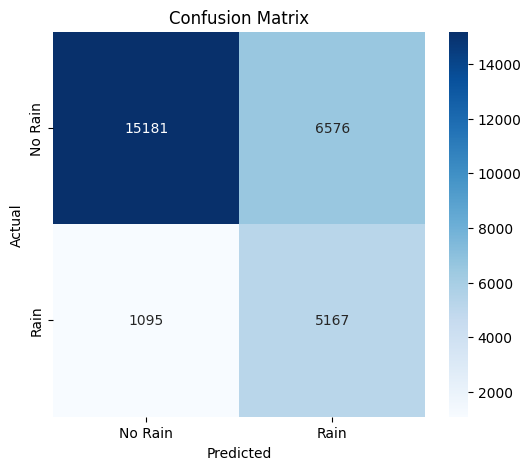

In [32]:
cm = confusion_matrix(y_test, y_pred_custom)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Rain", "Rain"],
    yticklabels=["No Rain", "Rain"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [33]:
y_pred_normal = y_pred_custom
y_proba_normal = y_proba

Avec SMOTE 

In [34]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Avant SMOTE :", np.bincount(y_train))
print("Après SMOTE :", np.bincount(y_train_smote))

Avant SMOTE : [87025 25047]
Après SMOTE : [87025 87025]


In [35]:
model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    random_state=42
)
clf = Pipeline(steps=[
    ("classifier", model)
])

clf.fit(X_train_smote, y_train_smote)
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

threshold = 0.45
y_pred_custom = (y_proba >= threshold).astype(int)


In [36]:
print("\n-----------Rapport de classification-----------")
print(classification_report(y_test, y_pred_custom))

accuracy = accuracy_score(y_test, y_pred_custom)
f1 = f1_score(y_test, y_pred_custom)
recall = recall_score(y_test, y_pred_custom)

print(f"Accuracy : {accuracy:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"Recall : {recall:.4f}")
print("ROC-AUC :", roc_auc_score(y_test, y_proba))


-----------Rapport de classification-----------
              precision    recall  f1-score   support

           0       0.90      0.83      0.87     21757
           1       0.54      0.69      0.61      6262

    accuracy                           0.80     28019
   macro avg       0.72      0.76      0.74     28019
weighted avg       0.82      0.80      0.81     28019

Accuracy : 0.8016
F1-score : 0.6073
Recall : 0.6864
ROC-AUC : 0.8393020777227729


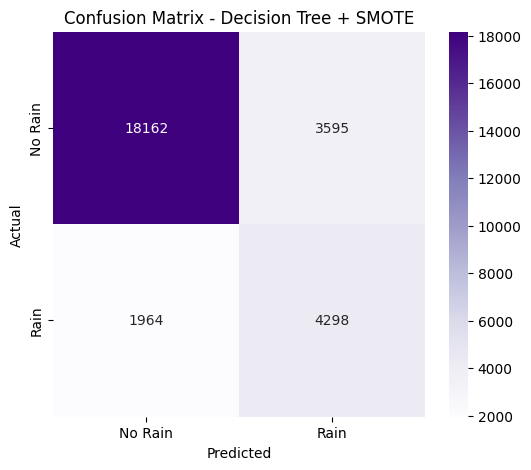

In [37]:

cm = confusion_matrix(y_test, y_pred_custom)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["No Rain", "Rain"],
    yticklabels=["No Rain", "Rain"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree + SMOTE")

plt.show()

In [38]:
y_pred_smote = y_pred_custom
y_proba_smote = y_proba

Pondération des classes (Cost-Sensitive Learning)

In [39]:
neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)

ratio = neg / pos
print("Ratio:", ratio)

Ratio: 3.4744680001596997


In [40]:
model = DecisionTreeClassifier(
    class_weight={0:1, 1:ratio},  # pondération automatique
    max_depth=10,
    min_samples_split=20,
    random_state=42
)


----------- Rapport de classification -----------
              precision    recall  f1-score   support

           0       0.92      0.75      0.83     21757
           1       0.48      0.78      0.59      6262

    accuracy                           0.76     28019
   macro avg       0.70      0.77      0.71     28019
weighted avg       0.82      0.76      0.78     28019

Accuracy : 0.7595560155608694
F1-score : 0.5911270255507677
Recall : 0.7777068029383584
ROC-AUC : 0.8408639894557296


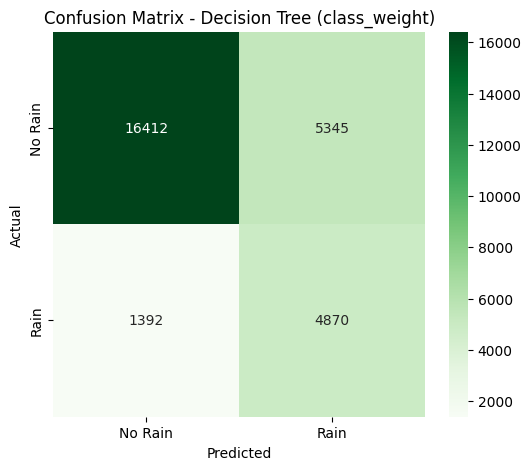

In [41]:
clf = Pipeline([
    ("classifier", model)
])

clf.fit(X_train, y_train)
y_proba = clf.predict_proba(X_test)[:,1]

threshold = 0.45
y_pred = (y_proba >= threshold).astype(int)

print("\n----------- Rapport de classification -----------")
print(classification_report(y_test, y_pred))

print("Accuracy :", accuracy_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("ROC-AUC :", roc_auc_score(y_test, y_proba))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Rain", "Rain"],
    yticklabels=["No Rain", "Rain"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree (class_weight)")
plt.show()

In [42]:
y_pred_weighted = y_pred
y_proba_weighted = y_proba

Comparaison Finale 

In [43]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score

results = pd.DataFrame({
    "Méthode": [
        "Decision Tree - Normal",
        "Decision Tree - SMOTE",
        "Decision Tree - Class Weight"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_smote),
        accuracy_score(y_test, y_pred_weighted)
    ],
    "Recall (Pluie)": [
        recall_score(y_test, y_pred_normal),
        recall_score(y_test, y_pred_smote),
        recall_score(y_test, y_pred_weighted)
    ],
    "F1-score (Pluie)": [
        f1_score(y_test, y_pred_normal),
        f1_score(y_test, y_pred_smote),
        f1_score(y_test, y_pred_weighted)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba_normal),
        roc_auc_score(y_test, y_proba_smote),
        roc_auc_score(y_test, y_proba_weighted)
    ]
})

results

,Méthode,Accuracy,Recall (Pluie),F1-score (Pluie),ROC-AUC
0,Decision Tree - Normal,0.759556,0.825136,0.573952,0.840977
1,Decision Tree - SMOTE,0.801599,0.686362,0.607277,0.839302
2,Decision Tree - Class Weight,0.759556,0.777707,0.591127,0.840864
